Photometric and Morphological Analysis of SDSS Galaxies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up a global style for all my plots
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11

print("Environment successfully configured.")

Environment successfully configured.


In [2]:
# Loading the SDSS dataset while skipping the metadata header line (#Table1)
df = pd.read_csv('/home/ignacio_p/Git/Data/sdss_100k_galaxy_form_burst.csv', skiprows=1)
df.head()

,objid,specobjid,ra,dec,u,g,r,i,z,modelFlux_u,...,psfMag_z,expAB_u,expAB_g,expAB_r,expAB_i,expAB_z,class,subclass,redshift,redshift_err
0,1237646587710669400,8175185722644649984,82.038679,0.847177,21.73818,20.26633,19.32409,18.64037,18.23833,2.007378,...,19.43575,0.099951,0.311864,0.289370,0.270588,0.187182,GALAXY,STARFORMING,0.067749,0.000015
1,1237646588247540577,8175186822156277760,82.138894,1.063072,20.66761,19.32016,18.67888,18.24693,18.04122,5.403369,...,18.85012,0.366549,0.516876,0.517447,0.552297,0.636966,GALAXY,STARFORMING,0.105118,0.000010
2,1237646588247540758,8175187097034184704,82.028510,1.104003,23.63531,21.19671,19.92297,19.31443,18.68396,0.295693,...,19.42235,0.050000,0.417137,0.506950,0.549881,0.370166,GALAXY,STARFORMING,0.234089,0.000030
3,1237648702973083853,332152325571373056,198.544469,-1.097059,20.12374,18.41520,17.47202,17.05297,16.72423,8.920645,...,18.03204,0.310763,0.356827,0.389345,0.388160,0.416660,GALAXY,STARFORMING,0.110825,0.000030
4,1237648702973149350,332154249716721664,198.706864,-1.046217,-9999.00000,-9999.00000,18.37762,18.13383,17.78497,0.000000,...,19.02880,-9999.000000,-9999.000000,0.050000,0.050000,0.149973,GALAXY,STARFORMING,0.136658,0.000021


In [ ]:
# Filtering out photometric noise and negative redshift values
df_clean = df[
    (df['u'].between(10, 30)) & 
    (df['g'].between(10, 30)) & 
    (df['r'].between(10, 30)) &
    (df['redshift'] > 0)
].copy()

# Checking how many rows were preserved after data quality control
print(f"Original rows: {df.shape[0]}")
print(f"Cleaned rows available for analysis: {df_clean.shape[0]}")

Original rows: 100000
Cleaned rows available for analysis: 99980


Color-Color Diagram

In [ ]:
# Calculating color indices to analyze stellar populations
df_clean['color_u_g'] = df_clean['u'] - df_clean['g']
df_clean['color_g_r'] = df_clean['g'] - df_clean['r']

# Displaying a quick preview
df_clean[['subclass', 'color_u_g', 'color_g_r', 'redshift', 'petroR50_r']].head()

,subclass,color_u_g,color_g_r,redshift,petroR50_r
0,STARFORMING,1.47185,0.94224,0.067749,1.638081
1,STARFORMING,1.34745,0.64128,0.105118,1.263937
2,STARFORMING,2.43860,1.27374,0.234089,0.987395
3,STARFORMING,1.70854,0.94318,0.110825,2.156205
5,STARFORMING,1.28898,0.65812,0.111458,1.983631


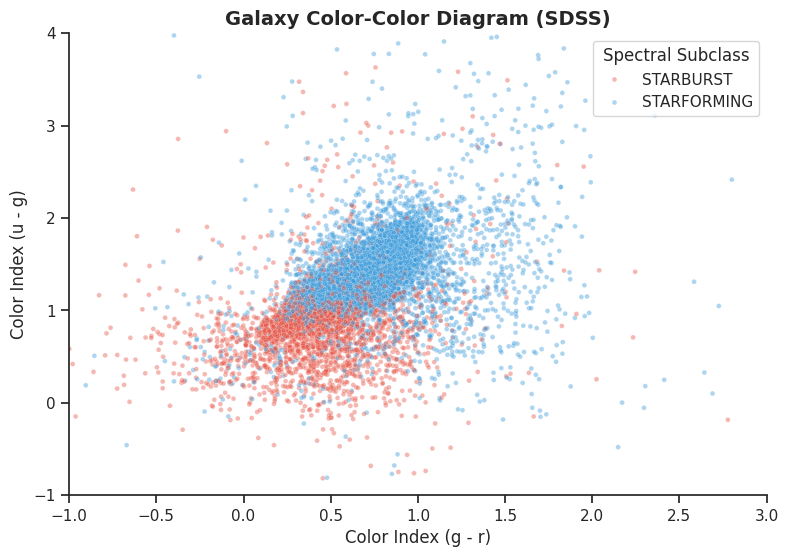

In [ ]:
plt.figure(figsize=(9, 6))

# Sampling the cleaned data to prevent overplotting and optimize rendering performance
df_sample = df_clean.sample(n=15000, random_state=42) if len(df_clean) > 15000 else df_clean

sns.scatterplot(
    data=df_sample,
    x='color_g_r',
    y='color_u_g',
    hue='subclass',
    palette={'STARFORMING': '#3498db', 'STARBURST': '#e74c3c'},
    alpha=0.4,
    s=12
)

# Adjusting axis limits to zoom in on the main galaxy population and crop out outliers
plt.xlim(-1, 3)
plt.ylim(-1, 4)

plt.title('Galaxy Color-Color Diagram (SDSS)', fontsize=14, fontweight='bold')
plt.xlabel('Color Index (g - r)', fontsize=12)
plt.ylabel('Color Index (u - g)', fontsize=12)
plt.legend(title='Spectral Subclass')
sns.despine()
plt.show()

Redshift Density Distribution

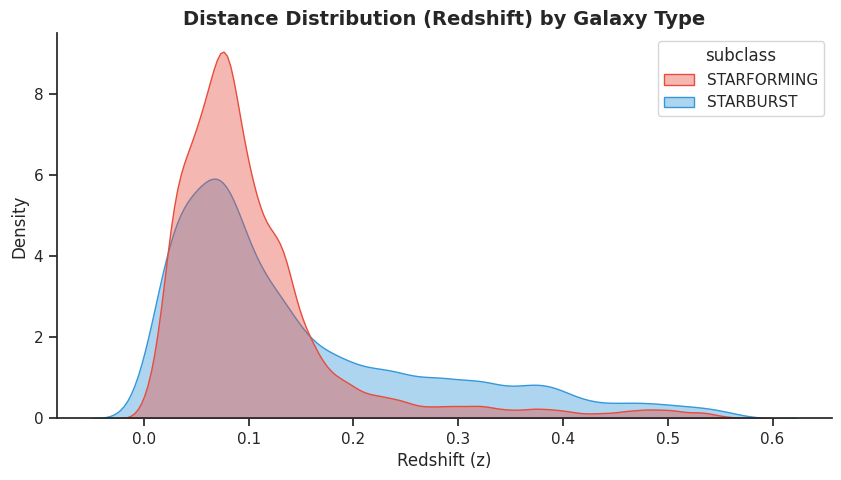

In [8]:
plt.figure(figsize=(10, 5))

# Using a Kernel Density Estimate (KDE) plot to smoothly compare both populations
sns.kdeplot(
    data=df_clean, 
    x='redshift', 
    hue='subclass', 
    fill=True, 
    common_norm=False, 
    palette={'STARFORMING': '#e74c3c', 'STARBURST': '#3498db'}, 
    alpha=0.4
)

plt.title('Distance Distribution (Redshift) by Galaxy Type', fontsize=14, fontweight='bold')
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel('Density', fontsize=12)
sns.despine()
plt.show()

Morphological Size Distribution

/tmp/ipykernel_54997/75736154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='subclass', y='petroR50_r', palette='Pastel2', showfliers=False)


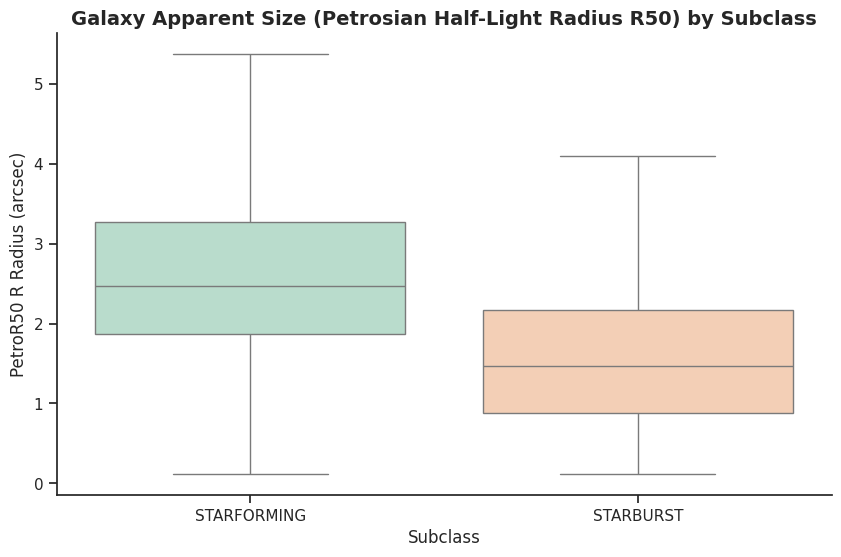

In [ ]:
plt.figure(figsize=(10, 6))

# Plotting galaxy size by subclass and hiding extreme outliers
sns.boxplot(data=df_clean, x='subclass', y='petroR50_r', palette='Pastel2', showfliers=False)

plt.title('Galaxy Apparent Size (Petrosian Half-Light Radius R50) by Subclass', fontsize=14, fontweight='bold')
plt.xlabel('Subclass', fontsize=12)
plt.ylabel('PetroR50 R Radius (arcsec)', fontsize=12)
sns.despine()
plt.show()